In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand

Testing Coded Least Square with Random Vectors
Random X Vector:  [0.01812755 0.07961568 0.10673062 0.16584094 0.22684351 0.23571327
 0.28773568 0.44591263 0.46269376 0.58324483 0.58717405 0.59695648
 0.66878205 0.71674559 0.75191287 0.77787967 0.79870583 0.82291989
 0.87492691 0.94439041]
Random Y Vector:  [0.75859534 0.68397215 0.26766863 0.02388597 0.19863745 0.50336333
 0.53789422 0.53392287 0.04957365 0.75593739 0.55881768 0.07251248
 0.59034027 0.91636074 0.43428654 0.84236294 0.25674872 0.87483503
 0.134219   0.3163748 ]
Random Data Linear Fit: y= 0.085903x+0.421907
Random Slope:  0.08590318964177356
Random Intercept:  0.4219073407253881 

Range Data:
True Line: y= -5.905481x+-0.153214
True Slope:  -5.905480837272945
True Intercept:  -0.15321446923713955
Custom Least Square:
Best fit: y= -5.658893x+-0.233949
Numpy Least Square:
Best fit: y= -5.658893x+-0.233949
Max Residual:  0.9776034262701506 at point X=  0.11
Min Residual:  -1.1115191918146525 at point X=  0.9400000000000001 


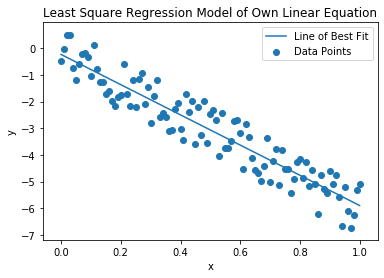

In [2]:
#My own least square apprach
def coded_least_square(X,Y):
    n=len(X)
    sum_x= np.sum(X)
    sum_y= np.sum(Y)
    sum_x2=np.sum(X**2)
    sum_xy=np.sum(X*Y)
    
    m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-(sum_x)**2)
    c=(sum_y-m*sum_x)/n
    return m,c

#Test least square regression with random points
Xrand=np.random.rand(20)
Yrand=np.random.rand(20)

idx=np.argsort(Xrand)
Xrand=Xrand[idx]
Yrand=Yrand[idx]

m_rand,c_rand=coded_least_square(Xrand,Yrand)
print("Testing Coded Least Square with Random Vectors")
print("Random X Vector: ", Xrand)
print("Random Y Vector: ", Yrand)
print(f"Random Data Linear Fit: y= {m_rand:.6f}x+{c_rand:.6f}")
print("Random Slope: ", m_rand)
print("Random Intercept: ", c_rand, "\n")

# data generation 
X=np.arange(0,1.01,.01)
m_true =np.random.uniform(-10, 10)
b_true =np.random.uniform(-2,2)
error= np.random.uniform(0,1,size=(len(X)))
sign=np.random.choice([-1,1],size=len(X))
random_error=sign*error
Y=m_true*X+b_true + random_error
print ("Range Data:")
print (f"True Line: y= {m_true:.6f}x+{b_true:.6f}")
print ("True Slope: ", m_true)
print ("True Intercept: ", b_true)

#custom vs numpy
m_custom, c_custom= coded_least_square(X,Y)
#numpy linear square
A=np.vstack([X,np.ones(len(X))]).T
m_numpy, c_numpy= np.linalg.lstsq(A,Y, rcond=None)[0]
print("Custom Least Square:")
print(f"Best fit: y= {m_custom:.6f}x+{c_custom:.6f}")
print("Numpy Least Square:")
print(f"Best fit: y= {m_numpy:.6f}x+{c_numpy:.6f}")
      
      
#Residuals
residuals= Y-(m_custom*X+c_custom)
max_residual= np.argmax(residuals) #when is says largest or smallest does that mean abs?
min_residual= np.argmin(residuals)
print ("Max Residual: ", residuals[max_residual], "at point X= ", X[max_residual])
print ("Min Residual: ", residuals[min_residual], "at point X= ", X[min_residual],"\n")

#print all residuals
print("Every Residual:")
for i in range (len(residuals)):
    print(residuals[i])
    
#Plotting 
plt.title("Least Square Regression Model of Own Linear Equation")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(X,m_custom*X+ c_custom, label='Line of Best Fit')
plt.scatter(X, Y,label='Data Points')
plt.legend()
plt.show()